In [31]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
iris = load_iris()

In [18]:
X = pd.DataFrame(iris.data)
X.columns = iris.feature_names
y = iris.target

In [19]:
X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<Axes: xlabel='sepal length (cm)', ylabel='petal length (cm)'>

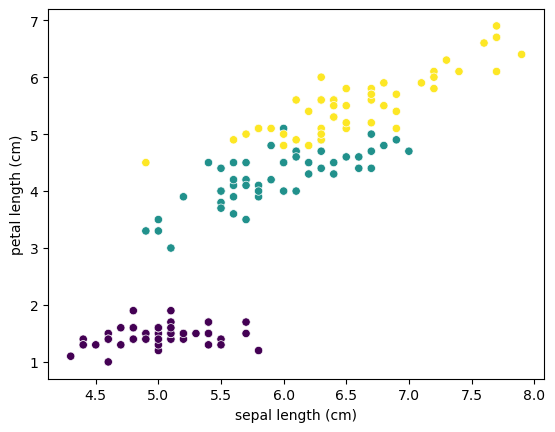

In [22]:
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 2], c=y)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [35]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)

pca_data = pca.fit_transform(X_scaled)

In [36]:
#Elbow method
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(pca_data)
    wcss.append(kmeans.inertia_)

<Axes: >

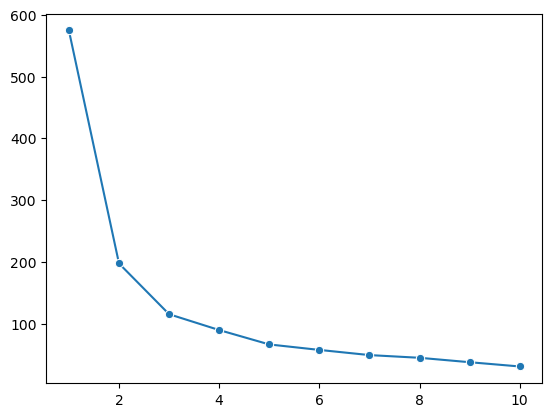

In [37]:
sns.lineplot(
    x = range(1,11),
    y = wcss,
    marker = "o"
)

<Axes: >

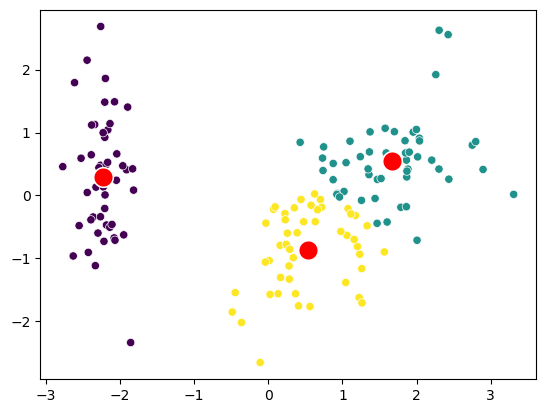

In [42]:
 #KMeans
kmeans = KMeans(n_clusters = 3)
labels = kmeans.fit_predict(pca_data)

sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], c = labels)
sns.scatterplot(x=kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1],marker = "o",c="red",s=200)